In [1]:
import arviz as az
import arviz_plots as azp
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm

az.style.use('arviz-darkgrid')
plt.style.use('ggplot')

g++ not available, if using conda: `conda install gxx`


# Bayesian Regularized Linear Models

In the previous notebook, we saw a variety of ways to fit a Bayesian generalized linear model to different cases using the link function. In each example we have done, we did not use informative priors since we had no prior knowledge to begin with. In this notebook, we will do something different and we will use priors such that maybe they do not incorporate prior information but they sure will help to shrink the coefficients of redundant predictors.

## Regularization as a Prior

To understand how we use priors for regularization purposes, we need to look at the mathematics to begin with. Since this is an applied course, I moved the derivations to the Appendix at the end of this notebook. Here I will only give the results and the intuition behind them.

It turns out that adding a penalty term to the loss function is exactly the same thing as putting a prior on the coefficients. The penalty is nothing but the negative logarithm of the prior density.

A normal prior on each coefficient

$\beta_j \sim \mathcal{N}(0,\tau^2)$

gives Ridge Regression, where

$\lambda = \frac{\sigma^2}{\tau^2}$

A Laplace prior on each coefficient

$\beta_j \sim \text{Laplace}(0,b)$

gives Lasso Regression, where

$\lambda = \frac{2\sigma^2}{b}$

Notice that $\sigma$ appears in both of them. It is the noise level of the data, and a Bayesian model estimates it instead of assuming it. So the amount of shrinkage is not a parameter we have to tune anymore, it adjusts itself to how noisy the data are.

### Intuition

**Ridge:** The normal distribution allows variability to a certain degree but the allowed variability is not too much. Like the example I gave at the end of the previous notebook, if I have an expected range for the variability, I can incorporate this knowledge using a normal distribution.

**Lasso:** The Laplace distribution is sharply peaked at zero and it has heavier tails than the normal distribution. So it says that most of the coefficients should be very close to zero, but the few that are not can be as large as the data requires. If I believe that only a handful of my predictors matter but I do not know which ones, this is the knowledge I can incorporate using a Laplace distribution.

The difference also shows itself in the penalty. The pull of the normal prior gets weaker as a coefficient approaches zero, so it never quite reaches it. The pull of the Laplace prior stays the same no matter how small the coefficient is, which is why it can push a coefficient all the way to zero.

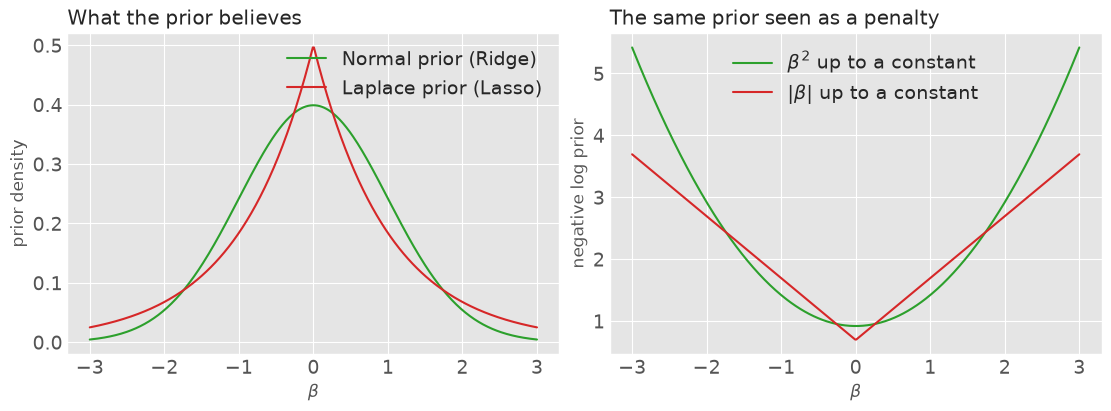

In [2]:
grid = np.linspace(-3, 3, 400)

normal_density = np.exp(-grid**2 / 2) / np.sqrt(2 * np.pi)
laplace_density = np.exp(-np.abs(grid)) / 2

fig, ax = plt.subplots(ncols = 2, figsize = (11, 4))

ax[0].plot(grid, normal_density, color = 'tab:green', label = 'Normal prior (Ridge)')
ax[0].plot(grid, laplace_density, color = 'tab:red', label = 'Laplace prior (Lasso)')
ax[0].set_xlabel(r'$\beta$')
ax[0].set_ylabel('prior density')
ax[0].set_title('What the prior believes', loc = 'left')
ax[0].legend()

ax[1].plot(grid, -np.log(normal_density), color = 'tab:green', label = r'$\beta^2$ up to a constant')
ax[1].plot(grid, -np.log(laplace_density), color = 'tab:red', label = r'$|\beta|$ up to a constant')
ax[1].set_xlabel(r'$\beta$')
ax[1].set_ylabel('negative log prior')
ax[1].set_title('The same prior seen as a penalty', loc = 'left')
ax[1].legend()

plt.show()

## Bayesian Ridge Regression

**Example**

$n = 20$

$\text{Number of informative features} = 2$

$\text{Number of redundant features} = 1$

Dataset:

$\beta_1 = 5$

$\beta_2 = 10$

$\beta_3 = 0$

$X_i \sim \mathcal{N}(0,1)\quad i = 1,2,3$

$\epsilon \sim \mathcal{N}(0,3^2)$

$y = \beta_1x_1 + \beta_2x_2 + \epsilon$

so $x_3$ carries no information at all and we expect a regularized model to say so.

Priors:

$\beta_i \sim \mathcal{N}(0,5^2)\quad i = 1,2,3$

$\sigma \sim \text{HalfCauchy}(0,5)$

Likelihood:

$y \mid X \sim \mathcal{N}(\mu,\sigma^2)$

where 

$\mu = \beta_1x_1 + \beta_2x_2 + \beta_3x_3$

In [3]:
np.random.seed(42)

n = 20
true_coefficients = np.array([5, 10, 0])

X = np.random.normal(loc = 0, scale = 1, size = (n, 3))
error = np.random.normal(loc = 0, scale = 3, size = n)
y = X @ true_coefficients + error

df = pd.DataFrame(X, columns = ["x1", "x2", "x3"])
df["y"] = y

print("true coefficients:", true_coefficients)

true coefficients: [ 5 10  0]


In [4]:
ridge_priors = {
    "x1": bmb.Prior("Normal", mu = 0, sigma = 5),
    "x2": bmb.Prior("Normal", mu = 0, sigma = 5),
    "x3": bmb.Prior("Normal", mu = 0, sigma = 5),
    "sigma": bmb.Prior("HalfCauchy", beta = 5)
}

bayesian_ridge = bmb.Model("y ~ x1 + x2 + x3", df, priors = ridge_priors)
ridge_fit = bayesian_ridge.fit(random_seed = 42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, x1, x2, x3]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 11 seconds.


In [5]:
az.summary(ridge_fit, kind = "stats", ci_prob = 0.95, ci_kind = "hdi")

,mean,sd,hdi95_lb,hdi95_ub
sigma,3.6,0.69,2.6,5.3
Intercept,-0.17,0.89,-1.9,1.6
x1,3.3,1.1,1.1,5.4
x2,9.8,0.84,8.1,11
x3,-0.48,0.87,-2.2,1.2


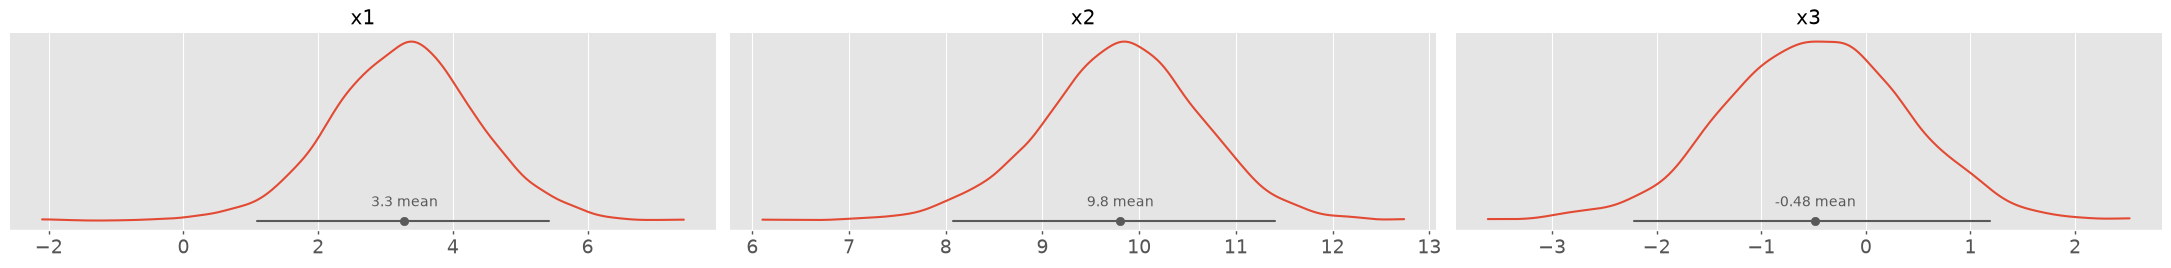

In [6]:
azp.plot_dist(ridge_fit, var_names = ["x1", "x2", "x3"], ci_prob = 0.95)

The model found $\beta_2$ perfectly, $\beta_1$ well and more importantly it assigned an HDI interval containing 0 for $\beta_3$. Now let's see how a Lasso model fits the same dataset.

## Bayesian Lasso Regression

Priors:

$\beta_i \sim \text{Laplace}(0,3.5)\quad i = 1,2,3$ (*)

$\sigma \sim \text{HalfCauchy}(0,5)$

Likelihood:

$y \mid X \sim \mathcal{N}(\mu,\sigma^2)$

where 

$\mu = \beta_1x_1 + \beta_2x_2 + \beta_3x_3$

(*) In the previous example we selected $\tau = 5$. To equalize the standard deviations of the two priors we will use 

$b = \tau / \sqrt{2} \approx 3.5$

In [7]:
lasso_priors = {
    "x1": bmb.Prior("Laplace", mu = 0, b = 3.5),
    "x2": bmb.Prior("Laplace", mu = 0, b = 3.5),
    "x3": bmb.Prior("Laplace", mu = 0, b = 3.5),
    "sigma": bmb.Prior("HalfCauchy", beta = 5)
}

bayesian_lasso = bmb.Model("y ~ x1 + x2 + x3", df, priors = lasso_priors)
lasso_fit = bayesian_lasso.fit(random_seed = 42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, x1, x2, x3]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 12 seconds.


In [8]:
az.summary(lasso_fit, ci_prob = 0.95, ci_kind = 'hdi')

,mean,sd,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma,3.62,0.68,2.6,5.2,3011,2994,1.00,0.013,0.011
Intercept,-0.11,0.89,-1.9,1.6,4323,3341,1.00,0.013,0.01
x1,3.07,1.17,0.7,5.4,3572,2643,1.00,0.02,0.015
x2,9.91,0.83,8.2,11,4340,3134,1.00,0.013,0.01
x3,-0.41,0.83,-2.1,1.2,4123,2974,1.00,0.013,0.01


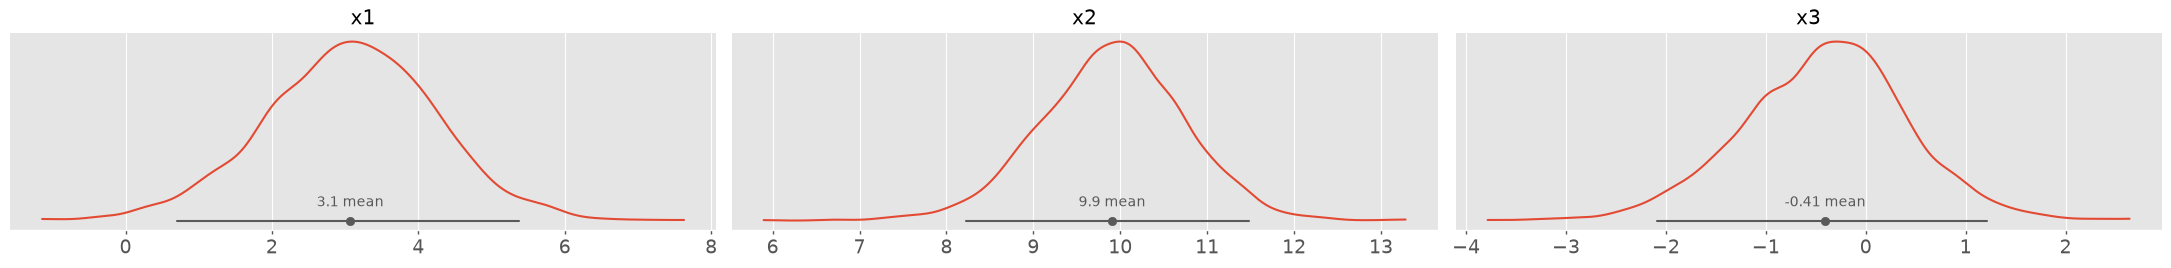

In [9]:
azp.plot_dist(lasso_fit, var_names = ["x1", "x2", "x3"], ci_prob = 0.95)

The Lasso regularization encourages the posterior density of $\beta_3$ to be slightly steeper. Also the posterior mean of $\beta_3$ is slightly closer to 0.

Notice that the final estimates are given as a distribution, not as a point estimate. Therefore unlike in the frequentist approach, Lasso regularization does not assign a coefficient as 0. It only pulls coefficients to 0 more powerfully compared to Ridge.

## Hierarchical Structure in Regularized Bayesian Linear Models

Traditionally, the optimal regularization parameter is found via using some kind of a cross validation method. Alternatively, in the Bayesian world we can find the optimal $\lambda$ by building a hierarchical model. Let's build hierarchical models for the same problem.

Ridge Priors:

$\beta_0 \sim \text{Flat}$

$\beta_i \sim \mathcal{N}(0,s^2)\quad i = 1,2,3$

where this time

$s \sim \text{HalfNormal}(0.75)$

We will keep the rest the same:

$\sigma \sim \text{HalfCauchy}(0,5)$

Likelihood:

$y \mid X \sim \mathcal{N}(\mu,\sigma^2)$

where

$\mu = \beta_0 + \beta_1x_1 + \beta_2x_2 + \beta_3x_3$

In [10]:
predictors = df[["x1", "x2", "x3"]].values

with pm.Model() as hierarchical_ridge_model:
    s = pm.HalfNormal("s", sigma = 0.75)

    intercept = pm.Flat("intercept")
    beta = pm.Normal("beta", mu = 0, sigma = s, shape = 3)
    sigma = pm.HalfCauchy("sigma", beta = 5)

    mu = intercept + pm.math.dot(predictors, beta)
    y_obs = pm.Normal("y_obs", mu = mu, sigma = sigma, observed = df["y"].values)

    hierarchical_ridge_fit = pm.sample(random_seed = 42, target_accept = 0.95)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [s, intercept, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 11 seconds.


In [11]:
az.summary(hierarchical_ridge_fit, ci_prob = 0.95, ci_kind = "hdi")

,mean,sd,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,-0.37,0.91,-2.2,1.4,3121,2672,1.00,0.016,0.012
beta[0],2.86,1.1,0.62,5,3215,2793,1.00,0.02,0.015
beta[1],9.03,1.01,6.8,11,2997,2417,1.00,0.019,0.017
beta[2],-0.48,0.88,-2.3,1.3,3044,2800,1.00,0.016,0.012
s,2.6,0.39,1.9,3.4,3556,2952,1.00,0.0066,0.005
sigma,3.83,0.81,2.6,5.7,2583,2711,1.00,0.017,0.02


Lasso Priors:

$\beta_0 \sim \text{Flat}$

$\beta_i \sim \text{Laplace}(0,s/\sqrt{2})\quad i = 1,2,3$ (*)

where this time

$s \sim \text{HalfNormal}(0.75)$

We will keep the rest the same:

$\sigma \sim \text{HalfCauchy}(0,5)$

Likelihood:

$y \mid X \sim \mathcal{N}(\mu,\sigma^2)$

where

$\mu = \beta_0 + \beta_1x_1 + \beta_2x_2 + \beta_3x_3$

(*) A $\text{Laplace}(0,b)$ prior has standard deviation $b\sqrt{2}$, so dividing $s$ by $\sqrt{2}$ makes the two models place the same spread on the coefficients. The only difference left between them is the shape of the prior.

In [12]:
with pm.Model() as hierarchical_lasso_model:
    s = pm.HalfNormal("s", sigma = 0.75)

    intercept = pm.Flat("intercept")
    beta = pm.Laplace("beta", mu = 0, b = s / np.sqrt(2), shape = 3)
    sigma = pm.HalfCauchy("sigma", beta = 5)

    mu = intercept + pm.math.dot(predictors, beta)
    y_obs = pm.Normal("y_obs", mu = mu, sigma = sigma, observed = df["y"].values)

    hierarchical_lasso_fit = pm.sample(random_seed = 42, target_accept = 0.95)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [s, intercept, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 12 seconds.


In [13]:
az.summary(hierarchical_lasso_fit, ci_prob = 0.95, ci_kind = "hdi")

,mean,sd,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,-0.16,0.88,-1.9,1.6,3239,2817,1.00,0.016,0.013
beta[0],2.55,1.17,0.18,4.8,2392,2503,1.00,0.024,0.017
beta[1],9.56,0.89,7.7,11,2852,2164,1.00,0.018,0.016
beta[2],-0.37,0.75,-1.9,1.1,3169,2562,1.00,0.013,0.01
s,2,0.42,1.2,2.9,3216,2786,1.00,0.0074,0.0056
sigma,3.71,0.74,2.6,5.5,2358,2274,1.00,0.016,0.016


In [14]:
def hierarchical_means(fit):
    posterior = fit.posterior
    return [posterior["beta"][:, :, j].mean().item() for j in range(3)] + \
           [posterior["s"].mean().item(), posterior["sigma"].mean().item()]

hierarchical_comparison = pd.DataFrame({
    "True": list(true_coefficients) + [np.nan, 3],
    "Hierarchical Ridge": hierarchical_means(hierarchical_ridge_fit),
    "Hierarchical Lasso": hierarchical_means(hierarchical_lasso_fit)
}, index = ["x1", "x2", "x3", "s", "sigma"])

hierarchical_comparison.round(3)

,True,Hierarchical Ridge,Hierarchical Lasso
x1,5.0,2.863,2.555
x2,10.0,9.025,9.556
x3,0.0,-0.481,-0.367
s,NaN,2.602,1.999
sigma,3.0,3.830,3.714


As expected, the Hierarchical Lasso model penalizes small coefficients more and large coefficients less due to its shape.

In conclusion, in this notebook we saw how to build regularized linear models using Bayesian Statistics. It comes with its upsides and downsides. The upside in this context is that this approach fixes the inference problem that we encountered in the frequentist approach. Since the results are given as intervals, we do not need further debiasing methods anymore. The downside is that building a regularized model in the Bayesian way is more complex and often requires more computational power. In the end, the true answer will be shaped depending on the problem that we are working on. To incorporate uncertainty and usage flexibility, the Bayesian approach is the way to go. For simplicity and quick answers, the frequentist approach will be better.

## Appendix

### Setting Up the Problem

Remember the Bayes theorem expression without the denominator:

$p(\beta \mid y) \propto p(y \mid \beta) \cdot p(\beta)$

If we take the logarithm of both sides:

$\log p(\beta \mid y) = \log p(y \mid \beta) + \log p(\beta) + \text{constant} \quad (1)$

For a linear model with a normal likelihood the first term is

$\log p(y \mid \beta) = -\frac{1}{2\sigma^2}\sum_{i=1}^{n}(y_i - x_i^\top\beta)^2 + \text{constant} \quad (2)$

If we combine $(1)$ and $(2)$

$\log p(\beta \mid y) = -\frac{1}{2\sigma^2}\sum_{i=1}^{n}(y_i - x_i^\top\beta)^2 + \log p(\beta) + \text{constant} \quad (3)$

We are searching for a $\beta$ value which maximizes $(3)$, or equivalently minimizes its negative:

$\frac{1}{2\sigma^2}\sum_{i=1}^{n}(y_i - x_i^\top\beta)^2 - \log p(\beta) \quad(4)$

The first term is the residual sum of squares. The second term is preventing $\beta$ from growing unnecessarily.

Now the question is how we can select such a prior.

### Normal Prior for Ridge Regression

Consider a normal prior assigned to each predictor in the model:

$\beta_j \sim \mathcal{N}(0,\tau^2)$

Then its density function will be

$p(\beta_j) = \frac{1}{\sqrt{2\pi\tau^2}}\exp\left(-\frac{\beta_j^2}{2\tau^2}\right)$

Since we assign this prior to each coefficient independently, the density of the whole vector is the product of them:

$p(\beta) = \prod_{j=1}^{p}\frac{1}{\sqrt{2\pi\tau^2}}\exp\left(-\frac{\beta_j^2}{2\tau^2}\right)$

If we take the logarithm of both sides:

$\log p(\beta) = \sum_{j=1}^{p}\left(-\log\sqrt{2\pi\tau^2} - \frac{\beta_j^2}{2\tau^2}\right)$

The terms containing $\beta$ affect the result, hence we write only these terms and the remaining ones will be collected as constant:

$\log p(\beta) = -\frac{1}{2\tau^2}\sum_{j=1}^{p}\beta_j^2 + \text{constant} \quad (5)$

Now if we put this into $(4)$

$\frac{1}{2\sigma^2}\sum_{i=1}^{n}(y_i - x_i^\top\beta)^2 + \frac{1}{2\tau^2}\sum_{j=1}^{p}\beta_j^2 \quad (6)$

If we multiply $(6)$ with $2\sigma^2$ (since it does not affect the place of the minimum) then

$\sum_{i=1}^{n}(y_i - x_i^\top\beta)^2 + \frac{\sigma^2}{\tau^2}\sum_{j=1}^{p}\beta_j^2 \quad (7)$

The $\frac{\sigma^2}{\tau^2}$ term is called $\lambda$, which we also defined in the "Regularized Linear Models" notebook.

$\sum_{i=1}^{n}(y_i - x_i^\top\beta)^2 + \lambda\sum_{j=1}^{p}\beta_j^2 \quad (8)$

### Laplace Prior for Lasso Regression

This time we will put a Laplace prior on each coefficient in the model:

$\beta_j \sim \text{Laplace}(0,b)$

Then its density function will be

$p(\beta_j) = \frac{1}{2b}\exp\left(-\frac{|\beta_j|}{b}\right)$

Since we assign this prior to each coefficient independently, the density of the whole vector is the product of them:

$p(\beta) = \prod_{j=1}^{p}\frac{1}{2b}\exp\left(-\frac{|\beta_j|}{b}\right)$

If we take the logarithm of both sides:

$\log p(\beta) = \sum_{j=1}^{p}\left(-\log 2b - \frac{|\beta_j|}{b}\right)$

The terms containing $\beta$ affect the result, hence we write only these terms and the remaining ones will be collected as constant:

$\log p(\beta) = -\frac{1}{b}\sum_{j=1}^{p}|\beta_j| + \text{constant} \quad (9)$

Now if we put this into $(4)$

$\frac{1}{2\sigma^2}\sum_{i=1}^{n}(y_i - x_i^\top\beta)^2 + \frac{1}{b}\sum_{j=1}^{p}|\beta_j| \quad (10)$

If we multiply $(10)$ with $2\sigma^2$ (since it does not affect the place of the minimum) then

$\sum_{i=1}^{n}(y_i - x_i^\top\beta)^2 + \frac{2\sigma^2}{b}\sum_{j=1}^{p}|\beta_j| \quad (11)$

Here the $\lambda$ term is

$\lambda = \frac{2\sigma^2}{b}$

which gives us Lasso Regression:

$\sum_{i=1}^{n}(y_i - x_i^\top\beta)^2 + \lambda\sum_{j=1}^{p}|\beta_j| \quad (12)$

Notice that the $2$ survived this time. In the normal case the exponent had $2\tau^2$ in its denominator, so multiplying by $2\sigma^2$ cancelled it. Here the denominator is only $b$, therefore the $2$ remains.